# L1.8 — Conflict detection

**Level 1 · Core · 40 minutes**

**Goal.** You can predict a conflict between two aircraft.

**Check at the end.** You can give a geometry where the detector says yes and no loss of separation
happens.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The contract

```python
class ConflictDetector:
    def detect(own, intr, rpz, t_lookahead) -> bool: ...
```

One directed pair, one instant, one answer. It has no memory and no state. Subclass it and write
this one method to add your own detector. Lesson L7.2 does that.

`StateBased` is the reference detector, and it has **no tunable parameters**. Everything that could
be tuned — the protected zone and the lookahead — is a property of the airspace, so it comes in as
an argument.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c"

from opencdarr import (
    M600,
    SMALL_FIXEDWING,
    MotionCommand,
    StateBased,
    create_aircraft,
    create_conflict,
    geo,
)
from opencdarr.cd.base import is_los
from opencdarr.kinematics import FixedWing, Multirotor
from opencdarr.relative import relative_enu, segment_min_range

RPZ = 50.0
LOOKAHEAD = 120.0
DETECT = StateBased()

own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0)
intr = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=60.0, rpz=RPZ, gs_intr=10.0)

print(f"detected: {DETECT.detect(own, intr, RPZ, LOOKAHEAD)}")
print(f"in loss now: {is_los(own, intr, RPZ)}")

detected: True
in loss now: False


## 2. What it computes

Take the relative position **r** and the relative velocity **v** of the pair. Then:

$$t_\text{CPA} = -\frac{\mathbf{r}\cdot\mathbf{v}}{|\mathbf{v}|^2}, \qquad
d_\text{CPA} = |\mathbf{r} + \mathbf{v}\,t_\text{CPA}|, \qquad
\tau = \frac{\sqrt{R^2 - d_\text{CPA}^2}}{|\mathbf{v}|}$$

`detect` returns `True` when **all three** hold:

1. $d_\text{CPA} < R$ — the straight-line paths come inside the protected zone at all.
2. $t_\text{CPA} - \tau < t_\text{lookahead}$ — the entry happens inside the horizon.
3. $t_\text{CPA} + \tau > 0$ — the exit has not already passed.

$\tau$ is the half-length of the time the pair would spend inside the zone. Calculate the three
yourself from `relative_enu` and check them against the detector.

In [2]:
def cpa(own_state, intr_state, rpz: float) -> dict[str, float]:
    """The three quantities StateBased works from, for one directed pair."""
    rel = relative_enu(own_state, intr_state)
    v2 = rel.vx ** 2 + rel.vy ** 2
    t_cpa = -(rel.rx * rel.vx + rel.ry * rel.vy) / v2
    d_cpa = np.hypot(rel.rx + rel.vx * t_cpa, rel.ry + rel.vy * t_cpa)
    tau = np.sqrt(max(rpz ** 2 - d_cpa ** 2, 0.0)) / np.sqrt(v2)
    return {"range": rel.dist, "t_cpa": t_cpa, "d_cpa": d_cpa, "tau": tau,
            "enters": t_cpa - tau, "leaves": t_cpa + tau}


c = cpa(own, intr, RPZ)
for name, value in c.items():
    print(f"  {name:<10}{value:>10.2f}")

print(f"\n  1. d_cpa < rpz            {c['d_cpa'] < RPZ}")
print(f"  2. enters < lookahead    {c['enters'] < LOOKAHEAD}")
print(f"  3. leaves > 0            {c['leaves'] > 0.0}")
print(f"  -> detect                {DETECT.detect(own, intr, RPZ, LOOKAHEAD)}")

  range         898.53
  t_cpa          63.54
  d_cpa           0.00
  tau             3.54
  enters         60.00
  leaves         67.07

  1. d_cpa < rpz            True
  2. enters < lookahead    True
  3. leaves > 0            True
  -> detect                True


## 3. The two boundaries

The miss distance sets one boundary, and it does not move with the lookahead. The lookahead sets the
other, and it does not move with the miss distance.

Sweep each one and find where the answer changes. The miss-distance boundary is `rpz` exactly: the
test is `d_cpa >= rpz -> no conflict`. `create_conflict` places the intruder on the geodesy, so the
achieved `d_cpa` sits within a few millimetres of the value you ask for. Print both, and do not read
anything into the last decimal.

In [3]:
print(f"miss distance, at a fixed lookahead of {LOOKAHEAD:.0f} s")
print(f"  {'asked for':>10}{'achieved d_cpa':>20}{'d_cpa - rpz':>15}{'detected':>11}")
for dcpa in (0.0, 20.0, 45.0, 49.0, 50.0, 51.0, 80.0):
    other = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=dcpa, tlos=60.0, rpz=RPZ,
                            gs_intr=10.0)
    achieved = cpa(own, other, RPZ)["d_cpa"]
    print(f"  {dcpa:>8.0f} m{achieved:>18.6f} m{achieved - RPZ:>+15.2e}"
          f"{str(DETECT.detect(own, other, RPZ, LOOKAHEAD)):>11}")

print(f"\nlookahead, at a crossing that enters the zone at t = {c['enters']:.0f} s")
for horizon in (10.0, 30.0, 55.0, 60.0, 90.0, 120.0):
    print(f"  lookahead {horizon:>5.0f} s   detected {DETECT.detect(own, intr, RPZ, horizon)}")

miss distance, at a fixed lookahead of 120 s
   asked for      achieved d_cpa    d_cpa - rpz   detected
         0 m          0.000000 m      -5.00e+01       True
        20 m         20.000000 m      -3.00e+01       True
        45 m         45.000000 m      -5.00e+00       True
        49 m         49.000000 m      -1.00e+00       True
        50 m         50.000000 m      -4.02e-10       True
        51 m         51.000000 m      +1.00e+00      False
        80 m         80.000000 m      +3.00e+01      False

lookahead, at a crossing that enters the zone at t = 60 s
  lookahead    10 s   detected False
  lookahead    30 s   detected False
  lookahead    55 s   detected False
  lookahead    60 s   detected False
  lookahead    90 s   detected True
  lookahead   120 s   detected True


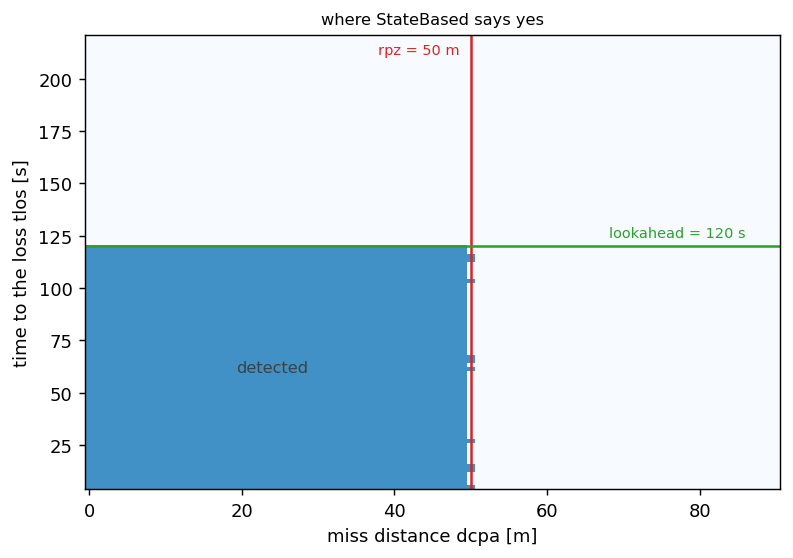

In [4]:
# the detection region over the two axes at once
dcpas = np.linspace(0.0, 90.0, 91)
tloss = np.linspace(5.0, 220.0, 108)
grid = np.zeros((len(tloss), len(dcpas)), dtype=bool)
for j, dcpa in enumerate(dcpas):
    for i, tlos in enumerate(tloss):
        other = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=float(dcpa), tlos=float(tlos),
                                rpz=RPZ, gs_intr=10.0)
        grid[i, j] = DETECT.detect(own, other, RPZ, LOOKAHEAD)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.pcolormesh(dcpas, tloss, grid, cmap="Blues", vmin=0, vmax=1.6, shading="nearest")
ax.axvline(RPZ, color=RED, lw=1.4)
ax.annotate(f"rpz = {RPZ:.0f} m", (RPZ, 212), (-6, 0), textcoords="offset points", ha="right",
            fontsize=8, color=RED)
ax.axhline(LOOKAHEAD, color=GREEN, lw=1.4)
ax.annotate(f"lookahead = {LOOKAHEAD:.0f} s", (86, LOOKAHEAD), (0, 5),
            textcoords="offset points", ha="right", fontsize=8, color=GREEN)
ax.annotate("detected", (24, 60), fontsize=9, color="0.25", ha="center")
ax.set_xlabel("miss distance dcpa [m]")
ax.set_ylabel("time to the loss tlos [s]")
ax.set_title("where StateBased says yes", fontsize=9)
fig.tight_layout()

## 4. Detection is a prediction. A loss is a fact.

`is_los(own, intr, rpz)` asks a different question: **are they inside the zone now?** It looks at
the present, and it has no lookahead.

| Function | Tense | Uses |
| --- | --- | --- |
| `detect(...)` | future | The straight-line extrapolation of the current velocities. |
| `is_los(...)` | present | The distance now. |

The runner measures the outcome with `is_los` on the **true** states. The separation logic decides
with `detect` on the **perceived** states. Those are two different inputs, and Level 2 is where the
gap opens.

## 5. A prediction that does not happen

`StateBased` extrapolates a **straight line**. Any aircraft that turns breaks that assumption.

Build one conflict, and fly it twice. The intruder holds its course in the first run and turns in
the second. The detector says the same thing at the start of both.

In [5]:
plane = create_aircraft(SMALL_FIXEDWING, id="INT", lat=intr.lat, lon=intr.lon, trk=intr.trk,
                        gs=17.0)
head_on = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=60.0, rpz=RPZ, gs_intr=17.0)
plane = create_aircraft(SMALL_FIXEDWING, id="INT", lat=head_on.lat, lon=head_on.lon,
                        trk=head_on.trk, gs=17.0)

print(f"detect at t = 0:  {DETECT.detect(own, plane, RPZ, LOOKAHEAD)}\n")

MR, FW, DT = Multirotor(), FixedWing(), 0.5


def fly_pair(course: float, n: int = 200):
    """Fly the pair with the intruder holding one course. Returns the two tracks and the minimum."""
    o, i = own, plane
    o_track, i_track, closest = [o], [i], []
    for _ in range(n):
        before = relative_enu(o, i)
        o = MR.step(o, MotionCommand.from_track_speed(0.0, 10.0), M600, DT)
        i = FW.step(i, MotionCommand(target_course=course, target_airspeed=17.0),
                    SMALL_FIXEDWING, DT)
        closest.append(segment_min_range(before, relative_enu(o, i)))
        o_track.append(o)
        i_track.append(i)
    return o_track, i_track, min(closest)


straight = fly_pair(plane.trk)                        # it holds the course it was detected on
turned = fly_pair((plane.trk + 45.0) % 360.0)         # it turns 45 deg, once, and holds that

print(f"{'the intruder':<26}{'true minimum':>15}{'loss of separation':>22}")
for label, run in (("holds its course", straight), ("turns 45 deg and holds", turned)):
    print(f"{label:<26}{run[2]:>13.1f} m{str(run[2] < RPZ):>22}")

detect at t = 0:  True

the intruder                 true minimum    loss of separation
holds its course                    0.1 m                  True
turns 45 deg and holds            624.0 m                 False


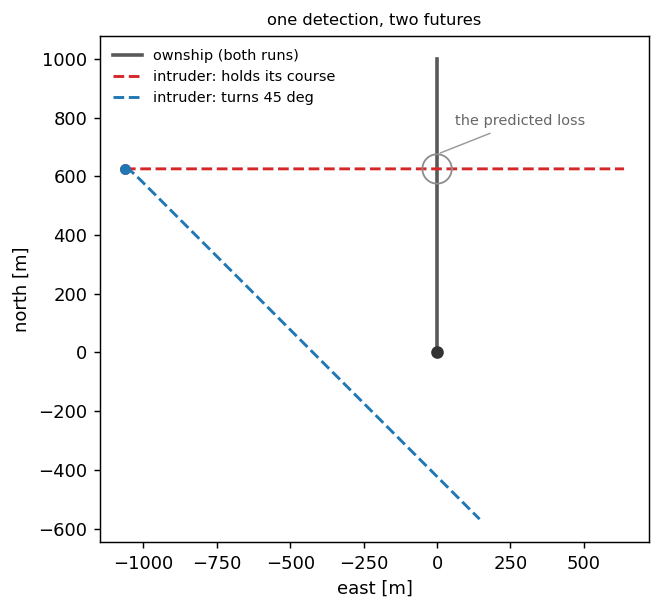

In [6]:
def enu_track(states) -> np.ndarray:
    return np.array([geo.enu(52.0, 4.0, s.lat, s.lon) for s in states])


fig, ax = plt.subplots(figsize=(7.4, 4.8))

own_xy = enu_track(straight[0])                       # the ownship flies the same way in both runs
ax.plot(own_xy[:, 0], own_xy[:, 1], lw=2.0, color="0.35", label="ownship (both runs)")
ax.plot(0, 0, marker="o", ms=6, color="0.2")

for (label, run), colour in ((("intruder: holds its course", straight), RED),
                             (("intruder: turns 45 deg", turned), BLUE)):
    p = enu_track(run[1])
    ax.plot(p[:, 0], p[:, 1], ls="--", lw=1.6, color=colour, label=label)
    ax.plot(p[0, 0], p[0, 1], marker="o", ms=5, color=colour)

# where the straight run actually came closest
gaps = [np.hypot(*(np.array(geo.enu(a.lat, a.lon, b.lat, b.lon))))
        for a, b in zip(straight[0], straight[1])]
k = int(np.argmin(gaps))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(own_xy[k, 0] + RPZ * np.cos(theta), own_xy[k, 1] + RPZ * np.sin(theta), lw=1.0,
        color="0.55")
ax.annotate("the predicted loss", (own_xy[k, 0], own_xy[k, 1] + RPZ), (10, 16),
            textcoords="offset points", fontsize=8, color="0.4",
            arrowprops=dict(arrowstyle="-", color="0.6", lw=0.8))

ax.set_aspect("equal")
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.set_title("one detection, two futures", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

So a detection is a statement about the **current** velocities, and nothing else. Three things break
it, and you meet all three later in this course:

| What breaks it | Where |
| --- | --- |
| An aircraft turns, so the straight line is wrong. | This lesson. |
| The resolver acts, so the predicted loss never happens. | Lesson L2.1. |
| The perceived state is not the true state, so the prediction starts from the wrong place. | Lesson L2.5. |

This is why `detection_rate` in a Monte-Carlo result is a **diagnostic** and never the answer.

## Do it yourself

1. Set `dpsi=180` (head-on) and repeat the sweep of section 3. Compare the boundary.
2. Make the pair fly parallel (`dpsi=0`, equal speeds). Read the detector, and say why.
3. Reverse the roles: call `detect(intr, own, ...)`. Check that it agrees. Say why it must.
4. Add a third aircraft and call `detect` for each pair yourself. Count the calls.

## Check

1. Detection is a prediction and a loss is a fact. Give a geometry where the detector says yes and
   no loss happens.
2. Which of the three conditions fails when the pair is already past its closest approach?
3. Why does `StateBased` take `rpz` and `t_lookahead` as arguments instead of as constructor
   parameters?

## Next

`L1.9 — Conflict resolution`. You can find the conflict. Next you calculate the way out of it.